In [1]:
#import the libraries and data
from prophet import Prophet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\MOTE THE ANALYST\Forecasting-HIV-new-infections-and-ART-coverage-in-Kenya-vs.-peer-countries\cleaned_hiv_data.csv")
df.head()

,Year,Code,country,adults(15-49)_prev(%),women_18_24_Prev(%),men_18_24_prev(%),total_deaths,total_children_deaths,total_adults_deaths,children_with_hiv,women_with_hiv,adults_with_hiv(15+),total_hiv_pop,adults_incidence_1000_uninfectedpop,total_incidence_1000_uninfectedpop,preg_women_antiretrovirals,newly_infected_children,newly_infected_adults,total_newly_infected
0,1990,ETH,Ethiopia,2.2,2.3,0.7,20000,8700,11000,40000,250000,430000,470000,6.3,3.4,29000,20000,120000,140000
1,1991,ETH,Ethiopia,2.6,2.7,0.8,26000,11000,15000,52000,320000,540000,590000,6.5,3.6,37000,24000,130000,150000
2,1992,ETH,Ethiopia,3.0,3.0,0.8,33000,13000,20000,64000,380000,630000,700000,6.0,3.4,44000,26000,120000,150000
3,1993,ETH,Ethiopia,3.3,3.1,0.8,40000,14000,26000,76000,430000,710000,790000,5.3,3.1,50000,28000,110000,140000
4,1994,ETH,Ethiopia,3.4,3.1,0.8,47000,15000,31000,88000,460000,760000,850000,4.3,2.7,55000,29000,91000,120000


# Model Comparison for New Infections forecast

Train: 31 | Test: 4


09:50:16 - cmdstanpy - INFO - Chain [1] start processing
09:50:17 - cmdstanpy - INFO - Chain [1] done processing


Prophet                   → MAPE: 151.03% | RMSE: 32712 | MAE: 32219
ARIMA                     → MAPE: 10.45% | RMSE: 2693 | MAE: 2124
Theta                     → MAPE: 35.22% | RMSE: 7907 | MAE: 7424
RandomForest              → MAPE: 14.70% | RMSE: 3517 | MAE: 3030

=== MODEL RANKING (Lower MAPE = Better) ===
 Rank        Model  MAPE (%)    RMSE     MAE
    1        ARIMA     10.45  2693.0  2124.0
    2 RandomForest     14.70  3517.0  3030.0
    3        Theta     35.22  7907.0  7424.0
    4      Prophet    151.03 32712.0 32219.0

✅ Best Model: ARIMA with MAPE of 10.45%


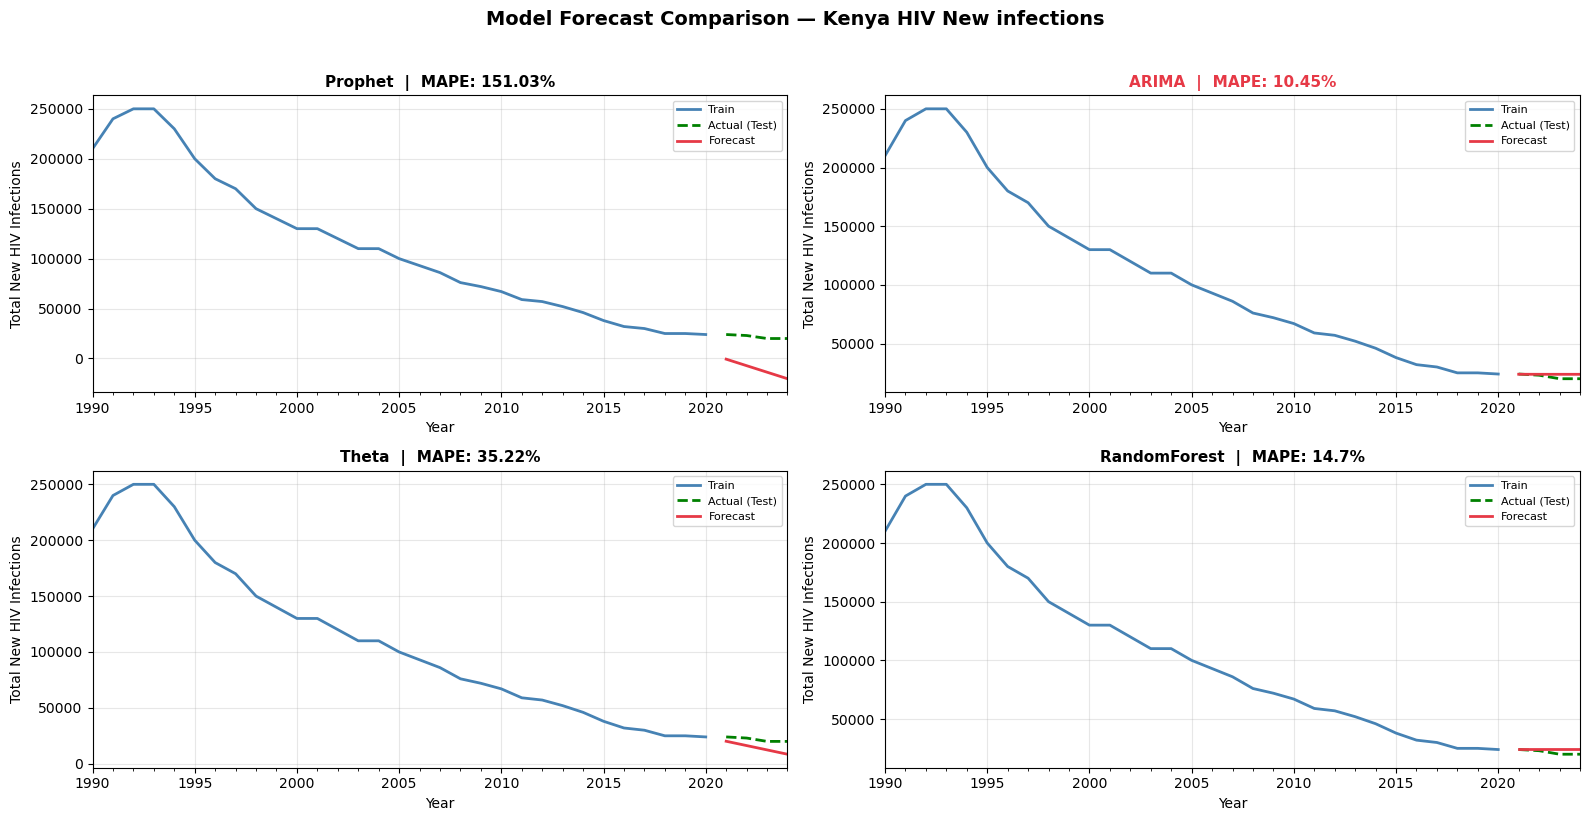

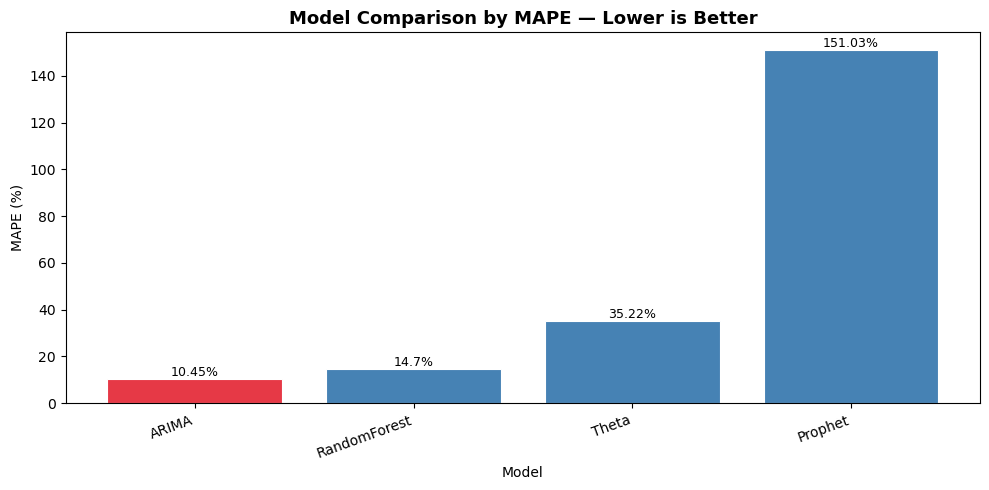

In [20]:
from darts.utils.utils import ModelMode
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import (
    Prophet, ARIMA, ExponentialSmoothing, Theta,
    RandomForestModel
)
from darts.metrics import mape, rmse, mae
import warnings
warnings.filterwarnings("ignore")

# ── CREATE TIMESERIES ─────────────────────────────────────────────────────────
ken_df = df[df['Code'] == 'KEN'].copy()
ken_df['Year'] = pd.to_datetime(ken_df['Year'], format='%Y')

series = TimeSeries.from_dataframe(
    ken_df,
    time_col='Year',
    value_cols='total_newly_infected'
)

# ── TRAIN/TEST SPLIT ──────────────────────────────────────────────────────────
train, test = series.split_before(0.92)
print(f"Train: {len(train)} | Test: {len(test)}")

# ── MODELS ────────────────────────────────────────────────────────────────────
models = {
    "Prophet"             : Prophet(yearly_seasonality=False, uncertainty_samples=1000),
    "ARIMA"               : ARIMA(p=1, d=1, q=0),
    "Theta"               : Theta(),
    "RandomForest"        : RandomForestModel(lags=3)
}

# ── EVALUATION LOOP ───────────────────────────────────────────────────────────
results   = []
forecasts = {}

for name, model in models.items():
    try:
        model.fit(train)
        forecast       = model.predict(len(test))
        forecasts[name] = forecast

        mape_score = mape(test, forecast)
        rmse_score = rmse(test, forecast)
        mae_score  = mae(test, forecast)

        results.append({
            'Model'   : name,
            'MAPE (%)': round(mape_score, 2),
            'RMSE'    : round(rmse_score, 0),
            'MAE'     : round(mae_score, 0),
        })
        print(f"{name:25} → MAPE: {mape_score:.2f}% | RMSE: {rmse_score:.0f} | MAE: {mae_score:.0f}")

    except Exception as e:
        print(f"  ❌ {name} failed: {e}")

# ── RESULTS TABLE ─────────────────────────────────────────────────────────────
results_df             = pd.DataFrame(results).sort_values('MAPE (%)').reset_index(drop=True)
results_df.index      += 1
results_df['Rank']     = results_df.index
best_model_name        = results_df.iloc[0]['Model']
best_mape              = results_df.iloc[0]['MAPE (%)']

print("\n=== MODEL RANKING (Lower MAPE = Better) ===")
print(results_df[['Rank', 'Model', 'MAPE (%)', 'RMSE', 'MAE']].to_string(index=False))
print(f"\n✅ Best Model: {best_model_name} with MAPE of {best_mape}%")

# ── FORECAST SUBPLOTS ─────────────────────────────────────────────────────────
n_models = len(forecasts)
ncols    = 2
nrows    = (n_models + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes      = axes.flatten()

for i, (name, forecast) in enumerate(forecasts.items()):
    ax        = axes[i]
    model_row = results_df[results_df['Model'] == name]
    mape_val  = model_row['MAPE (%)'].values[0] if not model_row.empty else 'N/A'

    # ✅ Fix: use .to_series()
    train.to_series().plot(   ax=ax, label='Train',         color='steelblue', linewidth=2)
    test.to_series().plot(    ax=ax, label='Actual (Test)', color='green',     linewidth=2, linestyle='--')
    forecast.to_series().plot(ax=ax, label='Forecast',      color='#e63946',   linewidth=2)

    ax.set_title(f"{name}  |  MAPE: {mape_val}%",
                 fontweight='bold', fontsize=11,
                 color='#e63946' if name == best_model_name else 'black')
    ax.set_xlabel("Year")
    ax.set_ylabel("Total New HIV Infections")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Model Forecast Comparison — Kenya HIV New infections",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── MAPE BAR CHART ────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
colors = ['#e63946' if m == best_model_name else 'steelblue'
          for m in results_df['Model']]
bars   = plt.bar(results_df['Model'], results_df['MAPE (%)'],
                 color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, results_df['MAPE (%)']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{val}%', ha='center', va='bottom', fontsize=9)

plt.title("Model Comparison by MAPE — Lower is Better", fontsize=13, fontweight='bold')
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig("NewInfectionsModelSelections.png", dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show()

=== CROSS-VALIDATION: ARIMA vs Theta Forecast ===
 Year  ARIMA_Forecast  Theta_Forecast  Lower_Estimate  Upper_Estimate
 2025           20000           16519           16519           20000
 2026           20000           13037           13037           20000
 2027           20000            9556            9556           20000
 2028           20000            6075            6075           20000
 2029           20000            2593            2593           20000
 2030           20000            -888            -888           20000
 2031           20000           -4370           -4370           20000
 2032           20000           -7851           -7851           20000
 2033           20000          -11332          -11332           20000
 2034           20000          -14814          -14814           20000


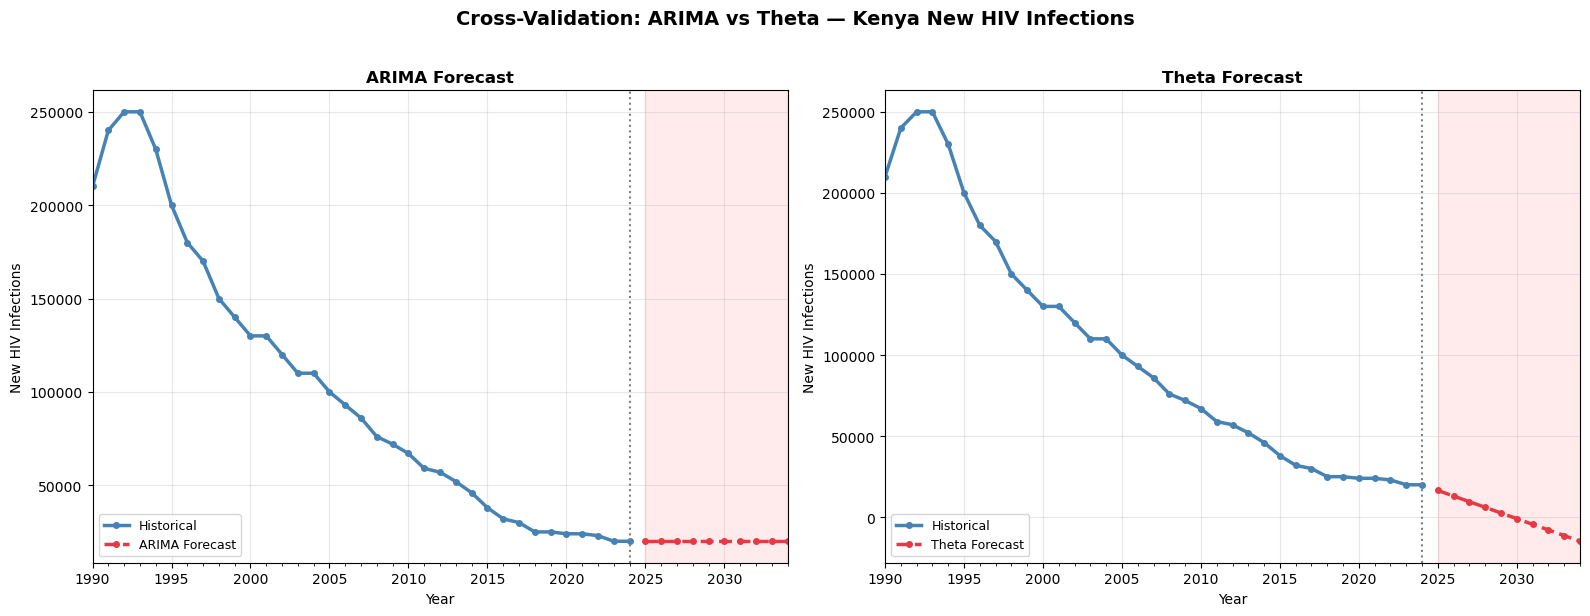

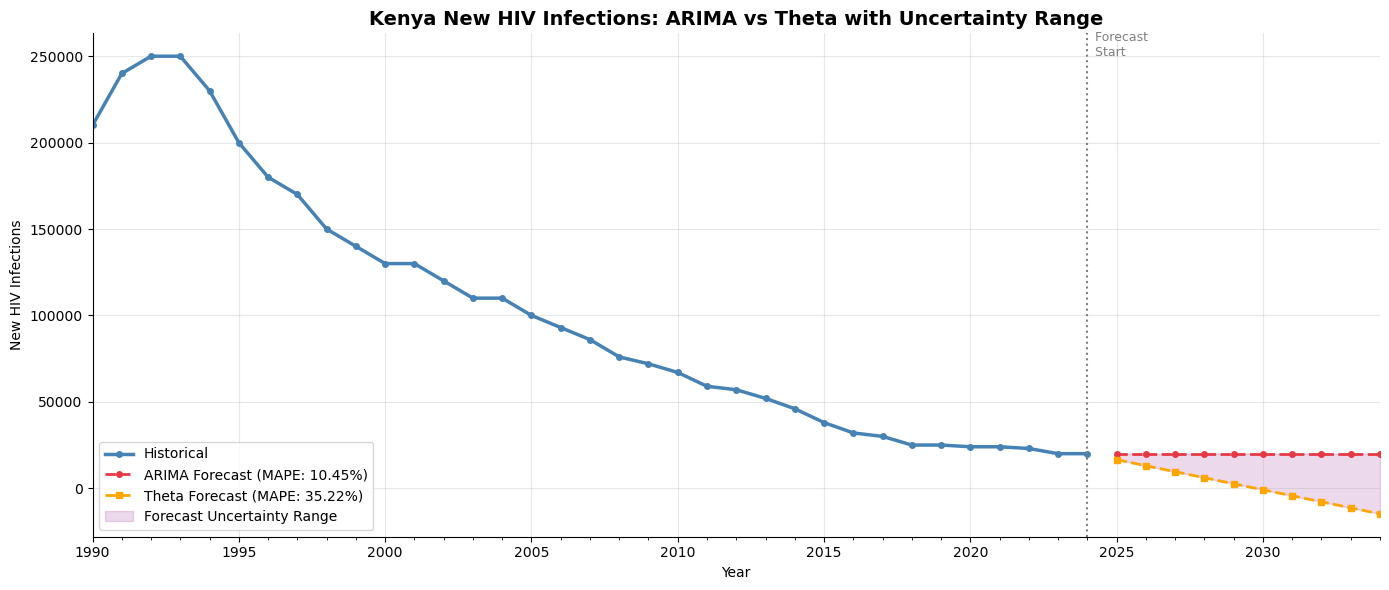


📊 Cross-Validation Summary
Year            ARIMA        Theta                Range
-------------------------------------------------------
2025           20,000       16,519   16,519 – 20,000
2026           20,000       13,037   13,037 – 20,000
2027           20,000        9,556   9,556 – 20,000
2028           20,000        6,075   6,075 – 20,000
2029           20,000        2,593   2,593 – 20,000
2030           20,000         -888   -888 – 20,000
2031           20,000       -4,370   -4,370 – 20,000
2032           20,000       -7,851   -7,851 – 20,000
2033           20,000      -11,332   -11,332 – 20,000
2034           20,000      -14,814   -14,814 – 20,000


In [22]:
from darts.models import ARIMA, Theta
import matplotlib.pyplot as plt
import pandas as pd

# ── STEP 1: RETRAIN BOTH MODELS ON FULL DATA ──────────────────────────────────
n_years = 10  # Change as needed

arima_model = ARIMA(p=1, d=1, q=0)
theta_model = Theta()

arima_model.fit(full_series)
theta_model.fit(full_series)

# ── STEP 2: FORECAST WITH BOTH ────────────────────────────────────────────────
arima_forecast = arima_model.predict(n_years)
theta_forecast = theta_model.predict(n_years)

# ── STEP 3: EXTRACT TO DATAFRAME ──────────────────────────────────────────────
arima_df = arima_forecast.to_dataframe().reset_index()
theta_df = theta_forecast.to_dataframe().reset_index()

arima_df.columns = ['Year', 'ARIMA_Forecast']
theta_df.columns = ['Year', 'Theta_Forecast']

arima_df['Year'] = arima_df['Year'].dt.year
theta_df['Year'] = theta_df['Year'].dt.year

# Merge into one comparison table
comparison_df = arima_df.merge(theta_df, on='Year')
comparison_df['ARIMA_Forecast'] = comparison_df['ARIMA_Forecast'].round(0).astype(int)
comparison_df['Theta_Forecast'] = comparison_df['Theta_Forecast'].round(0).astype(int)

# Agreement range (min to max of both models each year)
comparison_df['Lower_Estimate'] = comparison_df[['ARIMA_Forecast', 'Theta_Forecast']].min(axis=1)
comparison_df['Upper_Estimate'] = comparison_df[['ARIMA_Forecast', 'Theta_Forecast']].max(axis=1)

print("=== CROSS-VALIDATION: ARIMA vs Theta Forecast ===")
print(comparison_df.to_string(index=False))

# ── STEP 4: VISUALISE ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, forecast_series) in zip(axes, [("ARIMA", arima_forecast), ("Theta", theta_forecast)]):
    full_series.to_series().plot(
        ax=ax, label='Historical', color='steelblue', linewidth=2.5,
        marker='o', markersize=4
    )
    forecast_series.to_series().plot(
        ax=ax, label=f'{name} Forecast', color='#e63946',
        linewidth=2.5, linestyle='--', marker='o', markersize=4
    )
    ax.axvspan(
        forecast_series.to_series().index[0],
        forecast_series.to_series().index[-1],
        alpha=0.08, color='red'
    )
    ax.axvline(
        x=full_series.to_series().index[-1],
        color='gray', linestyle=':', linewidth=1.5
    )
    ax.set_title(f"{name} Forecast", fontsize=12, fontweight='bold')
    ax.set_xlabel("Year")
    ax.set_ylabel("New HIV Infections")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Cross-Validation: ARIMA vs Theta — Kenya New HIV Infections",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── STEP 5: COMBINED PLOT WITH UNCERTAINTY BAND ───────────────────────────────
plt.figure(figsize=(14, 6))

# Historical
full_series.to_series().plot(
    label='Historical', color='steelblue', linewidth=2.5,
    marker='o', markersize=4
)

# Both forecasts
arima_forecast.to_series().plot(
    label=f'ARIMA Forecast (MAPE: 10.45%)',
    color='#e63946', linewidth=2, linestyle='--', marker='o', markersize=4
)
theta_forecast.to_series().plot(
    label=f'Theta Forecast (MAPE: 35.22%)',
    color='orange', linewidth=2, linestyle='--', marker='s', markersize=4
)

# Uncertainty band between the two models
years = comparison_df['Year'].values
plt.fill_between(
    pd.to_datetime(years, format='%Y'),
    comparison_df['Lower_Estimate'],
    comparison_df['Upper_Estimate'],
    alpha=0.15, color='purple', label='Forecast Uncertainty Range'
)

plt.axvline(
    x=full_series.to_series().index[-1],
    color='gray', linestyle=':', linewidth=1.5
)
plt.text(
    full_series.to_series().index[-1],
    plt.ylim()[1] * 0.95,
    '  Forecast\n  Start',
    color='gray', fontsize=9
)

plt.title("Kenya New HIV Infections: ARIMA vs Theta with Uncertainty Range",
          fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("New HIV Infections")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("NewInfectionsforecast.png", dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show()

# ── STEP 6: SUMMARY ───────────────────────────────────────────────────────────
print("\n📊 Cross-Validation Summary")
print(f"{'Year':<8} {'ARIMA':>12} {'Theta':>12} {'Range':>20}")
print("-" * 55)
for _, row in comparison_df.iterrows():
    print(f"{int(row['Year']):<8} "
          f"{row['ARIMA_Forecast']:>12,} "
          f"{row['Theta_Forecast']:>12,} "
          f"  {row['Lower_Estimate']:,} – {row['Upper_Estimate']:,}")

Time series forecasting of epidemiological data is inherently uncertain. Rather than relying on a single model whose assumptions may not fully hold, using two complementary models provides a more robust and defensible forecast. ARIMA looks at recent momentum — if infections have been declining slowly recently, it expects that slow decline to continue. Theta looks at the entire historical trajectory — if infections have been declining for 30 years, it expects that broader trend to persist. Together they bracket the most likely range of outcomes.

**ARIMA — Flat Forecast (~20,000/year)**
ARIMA predicts new infections will plateau at around 20,000 throughout the entire forecast period. This suggests the model sees the current decline losing momentum — infections stabilizing rather than continuing to fall.

**Theta — Continued Decline**
Theta predicts new infections will continue declining, reaching near zero or very low levels by 2034. This follows the momentum of the historical downward trend and suggests Kenya could be approaching epidemic control within the decade.

**Uncertainty Band**
The shaded region between the two forecasts represents the plausible range of outcomes. The widening band over time reflects growing uncertainty — the further into the future, the less confident either model is.


# Model Comparison for ART Coverage forecast

In [23]:
# ART COVERAGE POST 2010

#loading Data
arv_coverage = pd.read_excel(r"C:\Users\MOTE THE ANALYST\Forecasting-HIV-new-infections-and-ART-coverage-in-Kenya-vs.-peer-countries\HIV Estimates Data.xlsx",sheet_name="ART_Coverage",header=[0])
print(f"this data covers from {arv_coverage['Year'].min()}, to {arv_coverage['Year'].max()}")

this data covers from 2010, to 2024


Train: 12 | Test: 3


10:15:27 - cmdstanpy - INFO - Chain [1] start processing
10:15:27 - cmdstanpy - INFO - Chain [1] done processing
ValueError: Train series only contains 12 elements but ARIMA(p=1) model requires at least 30 entries


Prophet                   → MAPE: 16.93% | RMSE: 15 | MAE: 15
  ❌ ARIMA failed: Train series only contains 12 elements but ARIMA(p=1) model requires at least 30 entries
Theta                     → MAPE: 3.53% | RMSE: 3 | MAE: 3
RandomForest              → MAPE: 7.22% | RMSE: 7 | MAE: 6

=== MODEL RANKING (Lower MAPE = Better) ===
 Rank        Model  MAPE (%)  RMSE  MAE
    1        Theta      3.53   3.0  3.0
    2 RandomForest      7.22   7.0  6.0
    3      Prophet     16.93  15.0 15.0

✅ Best Model: Theta with MAPE of 3.53%


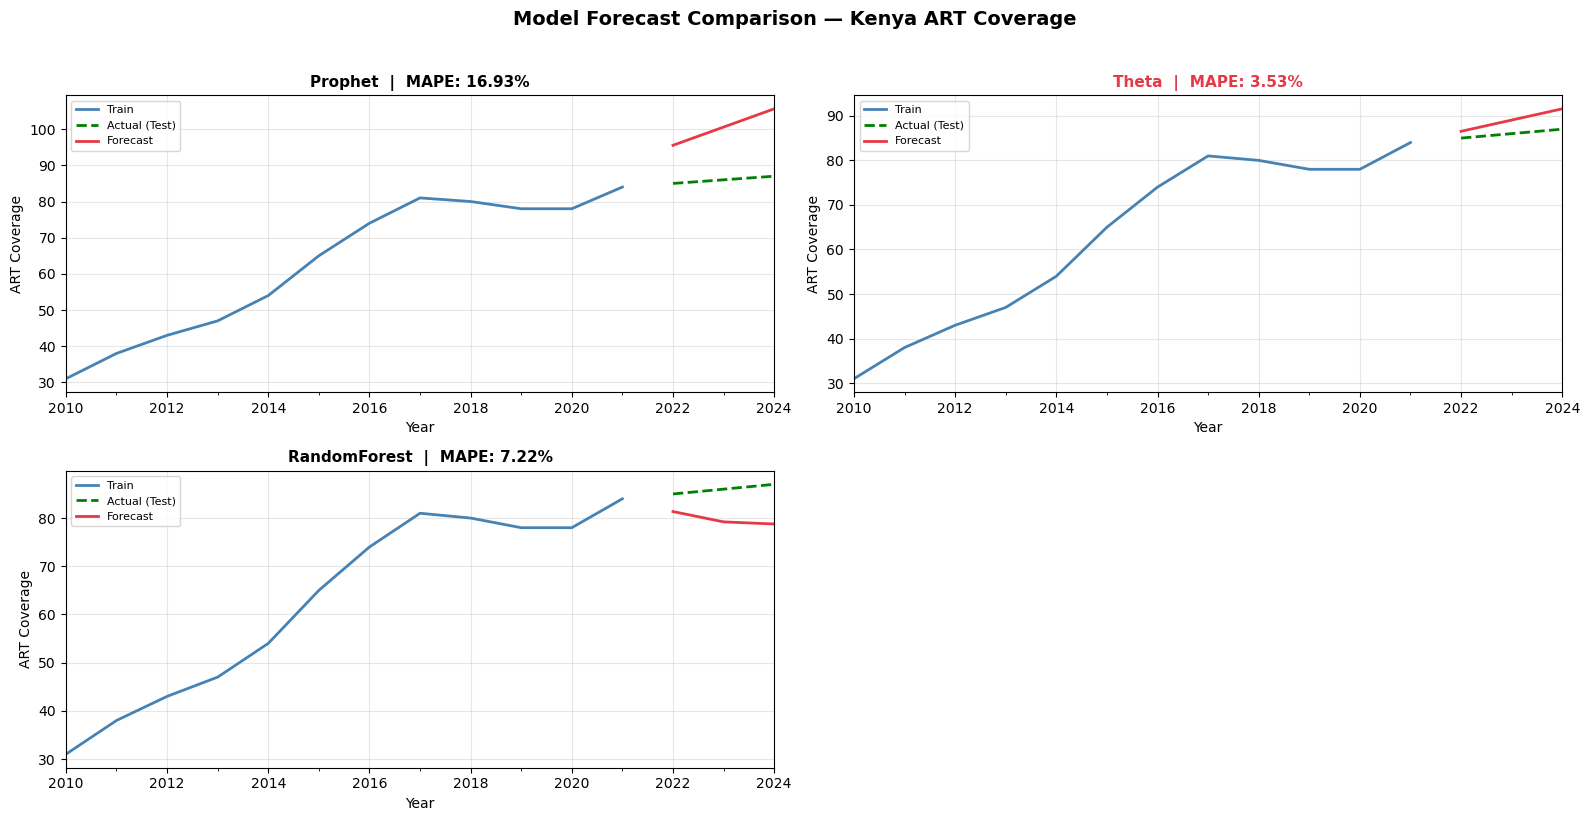

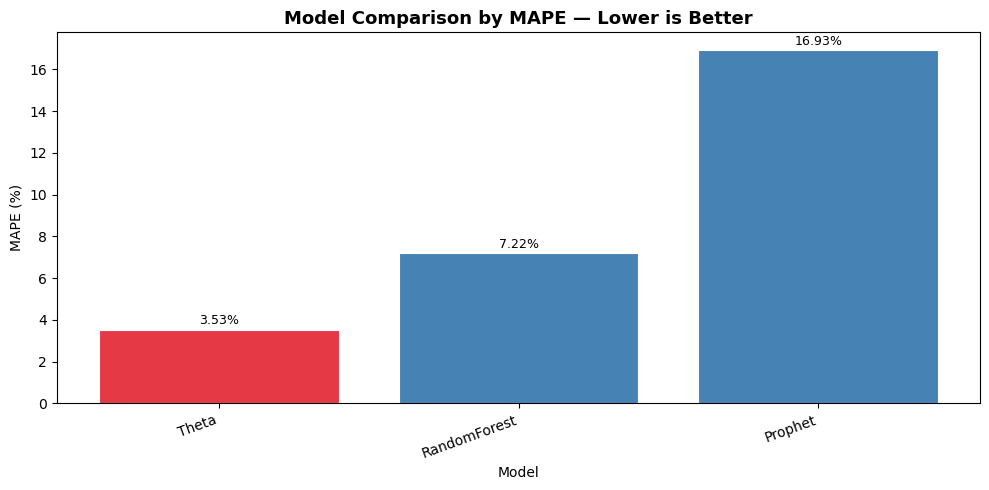

In [26]:
from darts.utils.utils import ModelMode
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import (
    Prophet, ARIMA, ExponentialSmoothing, Theta,
    RandomForestModel
)
from darts.metrics import mape, rmse, mae
import warnings
warnings.filterwarnings("ignore")

# ── CREATE TIMESERIES ─────────────────────────────────────────────────────────
ken_df = arv_coverage[arv_coverage['code'] == 'KEN'].copy()
ken_df['Year'] = pd.to_datetime(ken_df['Year'], format='%Y')

series = TimeSeries.from_dataframe(
    ken_df,
    time_col='Year',
    value_cols='PLHIV_ARV(%)'
)

# ── TRAIN/TEST SPLIT ──────────────────────────────────────────────────────────
train, test = series.split_before(0.92)
print(f"Train: {len(train)} | Test: {len(test)}")

# ── MODELS ────────────────────────────────────────────────────────────────────
models = {
    "Prophet"             : Prophet(yearly_seasonality=False, uncertainty_samples=1000),
    "ARIMA"               : ARIMA(p=1, d=1, q=0),
    "Theta"               : Theta(),
    "RandomForest"        : RandomForestModel(lags=3)
}

# ── EVALUATION LOOP ───────────────────────────────────────────────────────────
results   = []
forecasts = {}

for name, model in models.items():
    try:
        model.fit(train)
        forecast       = model.predict(len(test))
        forecasts[name] = forecast

        mape_score = mape(test, forecast)
        rmse_score = rmse(test, forecast)
        mae_score  = mae(test, forecast)

        results.append({
            'Model'   : name,
            'MAPE (%)': round(mape_score, 2),
            'RMSE'    : round(rmse_score, 0),
            'MAE'     : round(mae_score, 0),
        })
        print(f"{name:25} → MAPE: {mape_score:.2f}% | RMSE: {rmse_score:.0f} | MAE: {mae_score:.0f}")

    except Exception as e:
        print(f"  ❌ {name} failed: {e}")

# ── RESULTS TABLE ─────────────────────────────────────────────────────────────
results_df             = pd.DataFrame(results).sort_values('MAPE (%)').reset_index(drop=True)
results_df.index      += 1
results_df['Rank']     = results_df.index
best_model_name        = results_df.iloc[0]['Model']
best_mape              = results_df.iloc[0]['MAPE (%)']

print("\n=== MODEL RANKING (Lower MAPE = Better) ===")
print(results_df[['Rank', 'Model', 'MAPE (%)', 'RMSE', 'MAE']].to_string(index=False))
print(f"\n✅ Best Model: {best_model_name} with MAPE of {best_mape}%")

# ── FORECAST SUBPLOTS ─────────────────────────────────────────────────────────
n_models = len(forecasts)
ncols    = 2
nrows    = (n_models + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes      = axes.flatten()

for i, (name, forecast) in enumerate(forecasts.items()):
    ax        = axes[i]
    model_row = results_df[results_df['Model'] == name]
    mape_val  = model_row['MAPE (%)'].values[0] if not model_row.empty else 'N/A'

    # ✅ Fix: use .to_series()
    train.to_series().plot(   ax=ax, label='Train',         color='steelblue', linewidth=2)
    test.to_series().plot(    ax=ax, label='Actual (Test)', color='green',     linewidth=2, linestyle='--')
    forecast.to_series().plot(ax=ax, label='Forecast',      color='#e63946',   linewidth=2)

    ax.set_title(f"{name}  |  MAPE: {mape_val}%",
                 fontweight='bold', fontsize=11,
                 color='#e63946' if name == best_model_name else 'black')
    ax.set_xlabel("Year")
    ax.set_ylabel("ART Coverage")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Model Forecast Comparison — Kenya ART Coverage",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── MAPE BAR CHART ────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
colors = ['#e63946' if m == best_model_name else 'steelblue'
          for m in results_df['Model']]
bars   = plt.bar(results_df['Model'], results_df['MAPE (%)'],
                 color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, results_df['MAPE (%)']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{val}%', ha='center', va='bottom', fontsize=9)

plt.title("Model Comparison by MAPE — Lower is Better", fontsize=13, fontweight='bold')
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig("ARTCoverageModelSelections.png", dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show()

=== THETA FORECAST: Kenya New HIV Infections ===
 Year  PLHIV_ARV(%)
 2025         16519
 2026         13037
 2027          9556
 2028          6075
 2029          2593
 2030          -888
 2031         -4370
 2032         -7851
 2033        -11332
 2034        -14814


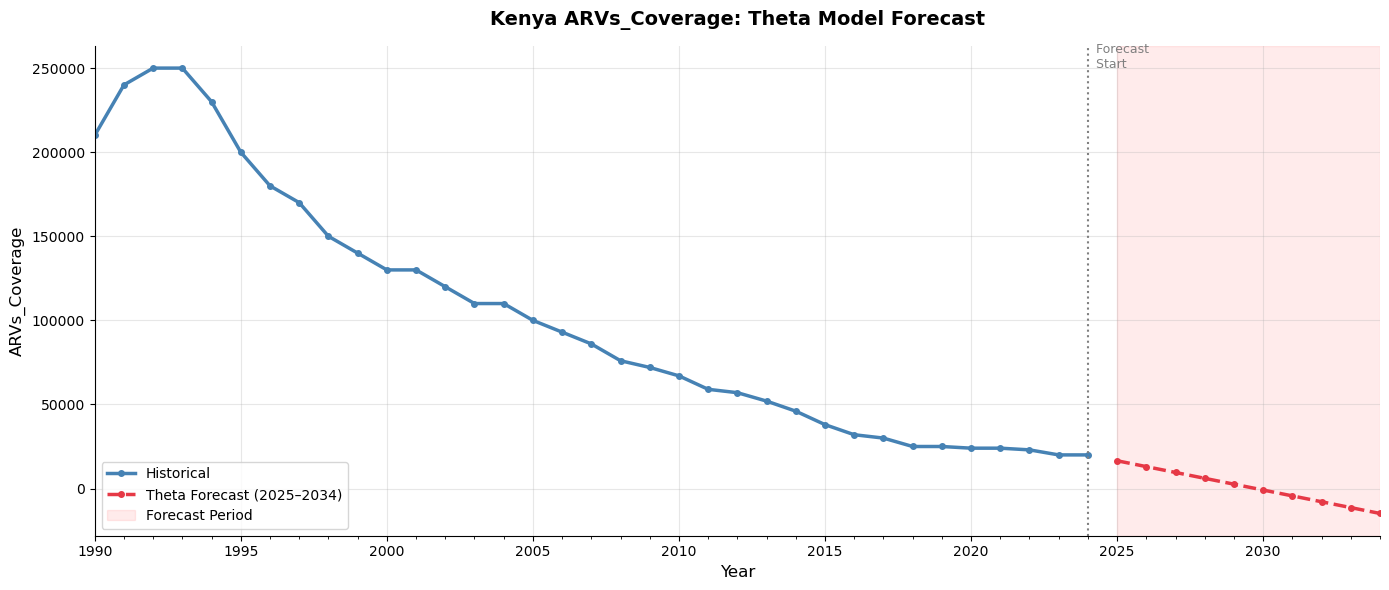


📊 Forecast Summary
   Model         : Theta
   MAPE on test  : 35.22%
   Forecast years: 2025 – 2034
   First year    : 16,519 infections
   Last year     : -14,814 infections
   Trend         : 📉 Declining


In [27]:
from darts.models import Theta

# ── STEP 1: RETRAIN ON FULL DATA ──────────────────────────────────────────────
theta_model = Theta()
theta_model.fit(full_series)

# ── STEP 2: FORECAST ──────────────────────────────────────────────────────────
n_years        = 10  # Change as needed
theta_forecast = theta_model.predict(n_years)

# ── STEP 3: EXTRACT FORECAST VALUES ───────────────────────────────────────────
forecast_df = theta_forecast.to_dataframe().reset_index()
forecast_df.columns = ['Year', 'PLHIV_ARV(%)']
forecast_df['Year'] = forecast_df['Year'].dt.year
forecast_df['PLHIV_ARV(%)'] = forecast_df['PLHIV_ARV(%)'].round(0).astype(int)

print("=== THETA FORECAST: Kenya New HIV Infections ===")
print(forecast_df.to_string(index=False))

# ── STEP 4: VISUALISE ─────────────────────────────────────────────────────────
plt.figure(figsize=(14, 6))

full_series.to_series().plot(
    label='Historical', color='steelblue',
    linewidth=2.5, marker='o', markersize=4
)
theta_forecast.to_series().plot(
    label=f'Theta Forecast ({forecast_df["Year"].min()}–{forecast_df["Year"].max()})',
    color='#e63946', linewidth=2.5, linestyle='--', marker='o', markersize=4
)

# Shade forecast region
plt.axvspan(
    theta_forecast.to_series().index[0],
    theta_forecast.to_series().index[-1],
    alpha=0.08, color='red', label='Forecast Period'
)

# Forecast start line
plt.axvline(
    x=full_series.to_series().index[-1],
    color='gray', linestyle=':', linewidth=1.5
)
plt.text(
    full_series.to_series().index[-1],
    plt.ylim()[1] * 0.95,
    '  Forecast\n  Start',
    color='gray', fontsize=9
)

plt.title("Kenya ARVs_Coverage: Theta Model Forecast",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("ARVs_Coverage", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# ── STEP 5: SUMMARY ───────────────────────────────────────────────────────────
print(f"\n📊 Forecast Summary")
print(f"   Model         : Theta")
print(f"   MAPE on test  : 35.22%")
print(f"   Forecast years: {forecast_df['Year'].min()} – {forecast_df['Year'].max()}")
print(f"   First year    : {forecast_df.iloc[0]['PLHIV_ARV(%)']:,} infections")
print(f"   Last year     : {forecast_df.iloc[-1]['PLHIV_ARV(%)']:,} infections")
trend = "📉 Declining" if forecast_df.iloc[-1]['PLHIV_ARV(%)'] < forecast_df.iloc[0]['PLHIV_ARV(%)'] else "📈 Increasing"
print(f"   Trend         : {trend}")